In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
from src.data_loader import load_data
from src.data_quality.consistency import generate_consistency_report, print_consistency_report
from src.data_quality.completess import generate_completeness_report, print_completeness_report
from src.utils.plotting import plot_correlation_heatmap, plot_outliers

## About this Dataset


### 📊 Synthetic Dataset Overview
Synthetic dataset of PV performance and associated meteorological variables for **38 sites** in the United States.  
Data sampled every **15 minutes**.  
🔗 Complete metadata available at: [Duramat Datahub](https://datahub.duramat.org/fr/dataset/metadata/synthetic-pv-performance-data)

---

### ⚡ Electricity Production Data
- 🕒 **Timestamp**: Date and time of recording (15-minute resolution).
- ⚙️ **Actual Power**: AC power measured at the inverter (without additional effects) — numerical values (e.g., kW).
- 🎯 **Reference Power**: Reference AC power including disruptive effects/losses (e.g., shading, drift, losses) — allows comparison with “ideal” production.

---

### 🌤️ Meteorological Data
- ☀️ **POA Irradiance (array tilt)**: Irradiance incident on the module plane (Plane-Of-Array), assuming correct sensor orientation (e.g., W/m²).
- 🌡️ **Ambient Temperature**: Ambient temperature (PSM3) (e.g., °C).
- 🌍 **GHI**: Global Horizontal Irradiance (PSM3) (e.g., W/m²).
- 💨 **Wind Speed**: Wind speed (PSM3) (e.g., m/s).

---



## 🎯 Study Goal
The objective this research is to predict the energy output that solar modules will generate on the following day based on the power generation data and weather measurements from the preceding day.

📝 NOTE: After a preliminary examination of both datasets, it is evident that whenever there is a significant number of missing values, the forecasting models start to strugle. As a result, I have chosen to focus exclusively on the data from plant 2 for this study, which has a more manageable 5% rate of missing values.

##  🧹📥 Load and Clean Data


This section loads the PV dataset from a CSV file and filters it to a specific time window based on the start date and duration.  
It ensures the data is timezone-aware and ready for analysis or visualization.


In [3]:
FILE_PATH = '/workspaces/solar_forecasting/data/interval_91_FT.csv'
# FILE_PATH = '/workspaces/solar_forecasting/data/interval_41_SAT.csv'
TIMEZONE = 'UTC-08:00'
DAYS = 15
START_DATE = '2020-07-01'
DAY_PLOT = '2020-07-10'

### General Data

In [4]:
data = load_data(FILE_PATH)

In [5]:
# # filter data for the specified date range
start_date = pd.Timestamp(START_DATE, tz=TIMEZONE)
end_date = start_date + pd.Timedelta(days=DAYS)
data = data[(data.index >= start_date) & (data.index < end_date)]

In [6]:
power_data = data[['actual power', 'reference power']]
weather_data = data[['poa irradiance (array tilt)', 'ambient temperature', 'ghi', 'wind speed']]

### 1 - Power generation data

In [7]:
report_consystency_power = generate_consistency_report(power_data, timestamp_col=None, expected_freq='15min', df_type='power')
print_consistency_report(report_consystency_power) 

=== Data Consistency Report ===
Detected/forced type: power
Schema used: ['actual power', 'reference power']
Missing columns: []
Extra columns: []
Dtype mismatches: 0
Duplicate index rows: 0, 
Timestamp info: {'index_is_datetime': True, 'tz': 'UTC-08:00', 'is_monotonic_increasing': True, 'inferred_freq': '15min'}
Frequency/gaps: missing=0, misaligned=0


There are no missing datetimes or columns in the dataset. All column data types match the expected formats.

In [8]:
report_completeness_power = generate_completeness_report(power_data, timestamp_col=None, expected_freq='15min')
print_completeness_report(report_completeness_power)

=== Data Completeness Report ===
Total rows present: 1440
Expected rows (range/freq): 1440
Missing timestamps: 0 (0.0%)
Duplicated index entries: 0

Per-column missingness:
 - actual power: 0 missing (0.0%), longest NaN run = 0 samples, duration = 0 days 00:00:00
 - reference power: 0 missing (0.0%), longest NaN run = 0 samples, duration = 0 days 00:00:00


### 2 - Weather data

In [9]:
report_consystency_weather = generate_consistency_report(weather_data, timestamp_col=None, expected_freq='15min', df_type='meteo')
print_consistency_report(report_consystency_weather) 

=== Data Consistency Report ===
Detected/forced type: meteo
Schema used: ['poa irradiance (array tilt)', 'ambient temperature', 'ghi', 'wind speed']
Missing columns: []
Extra columns: []
Dtype mismatches: 0
Duplicate index rows: 0, 
Timestamp info: {'index_is_datetime': True, 'tz': 'UTC-08:00', 'is_monotonic_increasing': True, 'inferred_freq': '15min'}
Frequency/gaps: missing=0, misaligned=0


In [10]:
report_completness_weather = generate_completeness_report(weather_data, timestamp_col=None, expected_freq='15min')
print_completeness_report(report_completness_weather)

=== Data Completeness Report ===
Total rows present: 1440
Expected rows (range/freq): 1440
Missing timestamps: 0 (0.0%)
Duplicated index entries: 0

Per-column missingness:
 - poa irradiance (array tilt): 0 missing (0.0%), longest NaN run = 0 samples, duration = 0 days 00:00:00
 - ambient temperature: 0 missing (0.0%), longest NaN run = 0 samples, duration = 0 days 00:00:00
 - ghi: 0 missing (0.0%), longest NaN run = 0 samples, duration = 0 days 00:00:00
 - wind speed: 0 missing (0.0%), longest NaN run = 0 samples, duration = 0 days 00:00:00


## Exploratory Analysis

In [11]:
# We extract more features from DATE_TIME
data['hour'] = data.index.hour
data['dayofweek'] = data.index.dayofweek

# Convert day of year to days of our study period (1-30)
days = data.index.dayofyear
data['day'] = days.map({days.unique()[i-1]:i for i in range(1, DAYS+1)})

# Step 1: Extract time values from the index as a Series
time_series = pd.Series(data.index.time, index=data.index)

# Step 2: Get sorted unique time values
unique_times = sorted(time_series.unique())

# Step 3: Create a mapping dictionary from time to interval label (1 to 96)
time_to_interval = {t: i+1 for i, t in enumerate(unique_times)}
# Step 4: Map the time values to interval labels
data['interval'] = time_series.map(time_to_interval)

In [12]:
# use data without missing values for the moment
df_na = data[~data.isna()]

## Data Correlation

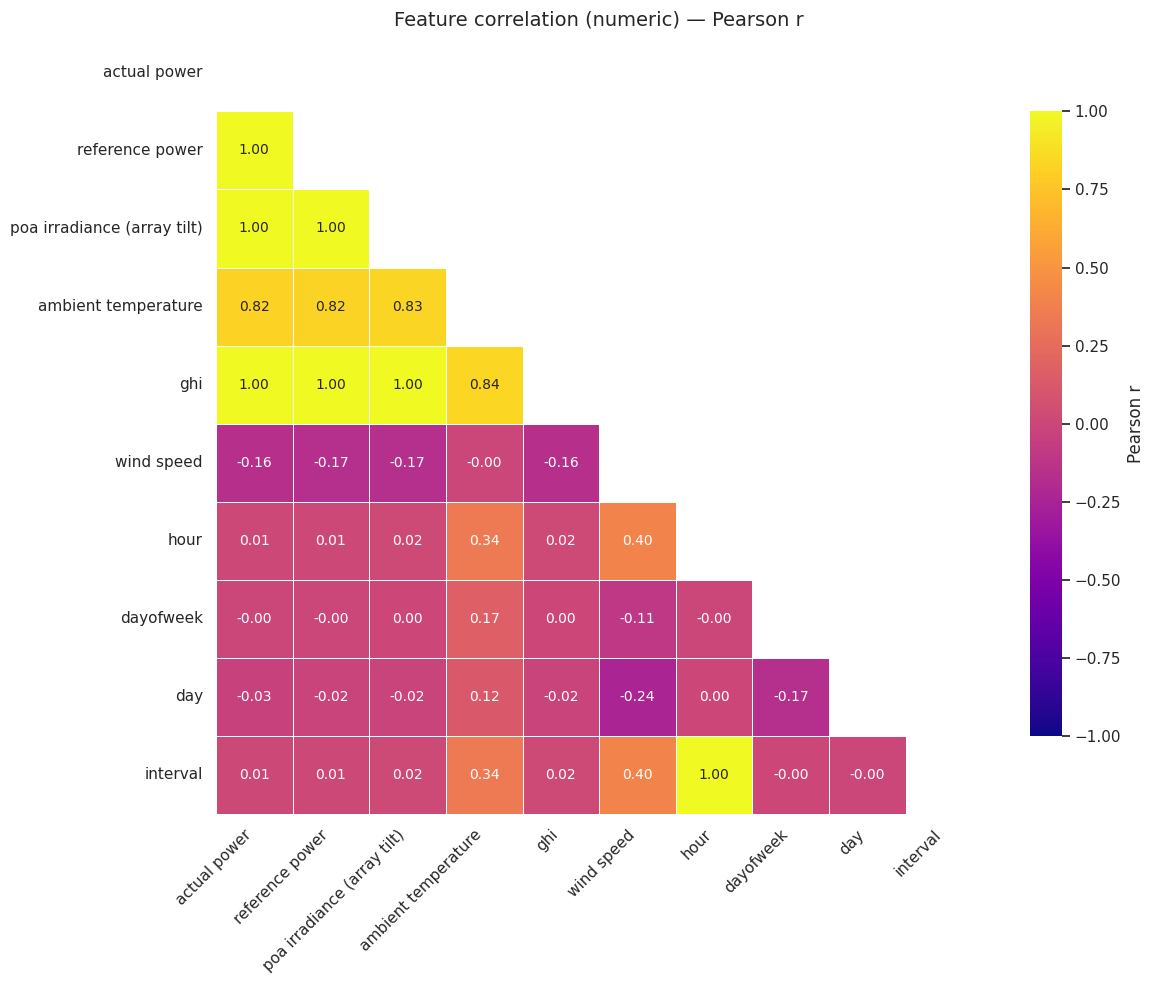

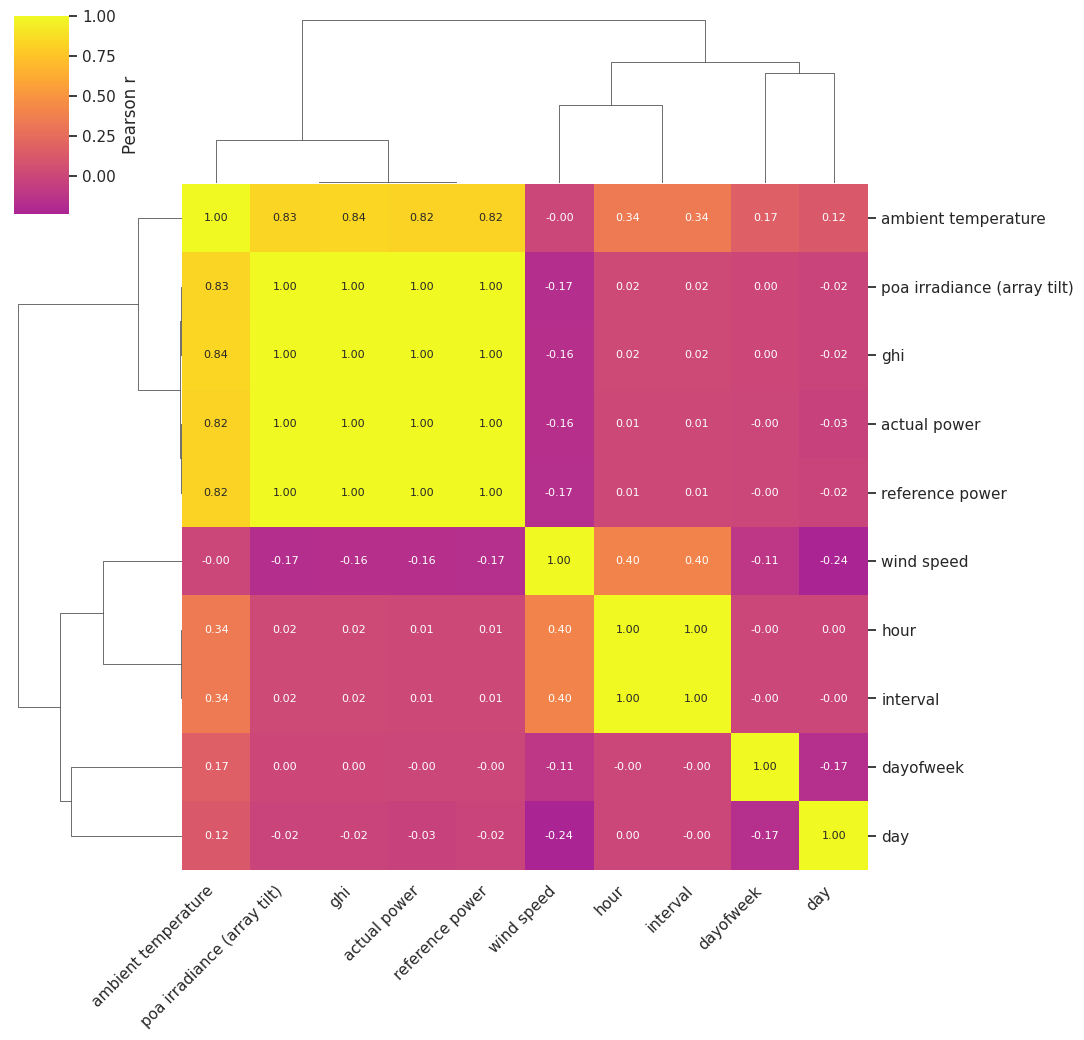

In [13]:
plot_correlation_heatmap(df_na)

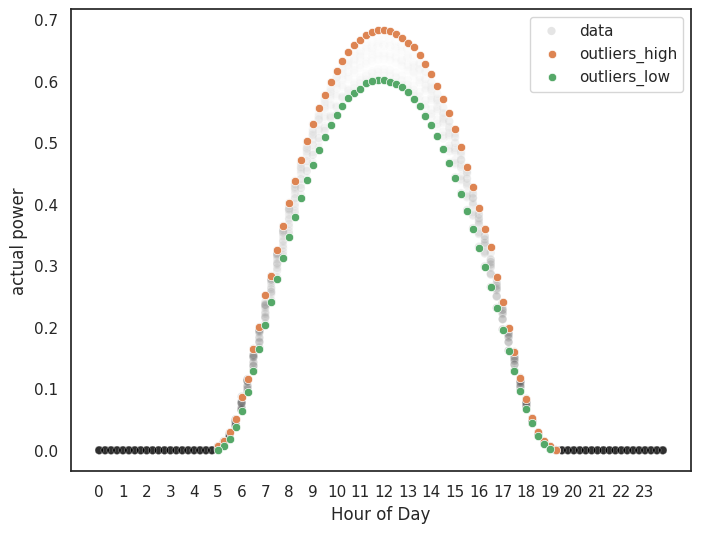

In [14]:
plot_outliers(df_na, "actual power")

In [15]:
data.index = pd.to_datetime(data.index.strftime('%d-%m-%Y %H:%M'), format='%d-%m-%Y %H:%M')

In [16]:
data_all = pd.concat([data.groupby(data.index).sum(numeric_only=True)[power_data.columns],
                       data.groupby(data.index).mean(numeric_only=True)[weather_data.columns]], axis=1)

# add datetime features
data_all['hour'] = data_all.index.hour
data_all['dayofweek'] = data_all.index.dayofweek
data_all['day'] = data_all.index.dayofyear
data_all['day'] = data_all.day.map({data_all.day.unique()[i-1]:i for i in range(1, DAYS+1)})
data_all['interval'] = data_all.index.time
data_all['interval'] = data_all.interval.map({unique_times[i-1]: i for i in range(1, len(unique_times)+1)})

In [17]:
day = 96 # 24*4 (for each 15min intervall)
# shift all data by 1 day so that each features sample
# corresponds to the next day AC_POWER generated
target = data_all['actual power'].shift(-day).dropna()
features = data_all[~data_all['actual power'].shift(-day).isna()]

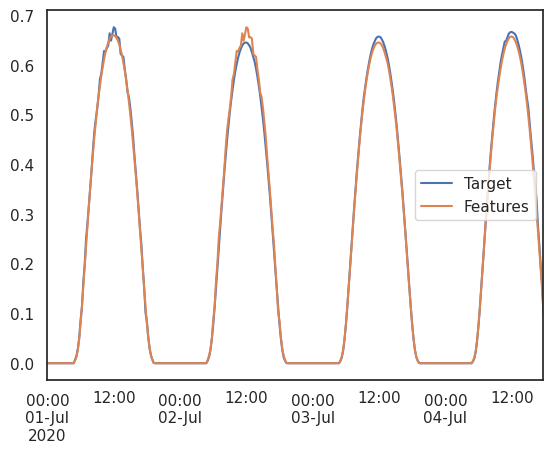

In [18]:
target.iloc[:360].plot(label='Target')
features['actual power'].iloc[:360].plot(label='Features')
plt.legend()

In [19]:
power_features = power_data.columns
weather_features = weather_data.columns

In [20]:
# last 4 days will be reserved for testing
split_datetime = -day*4
x_train = features.iloc[:split_datetime]
x_test = features.iloc[split_datetime:]
y_train = target[:split_datetime]
y_test = target[split_datetime:]

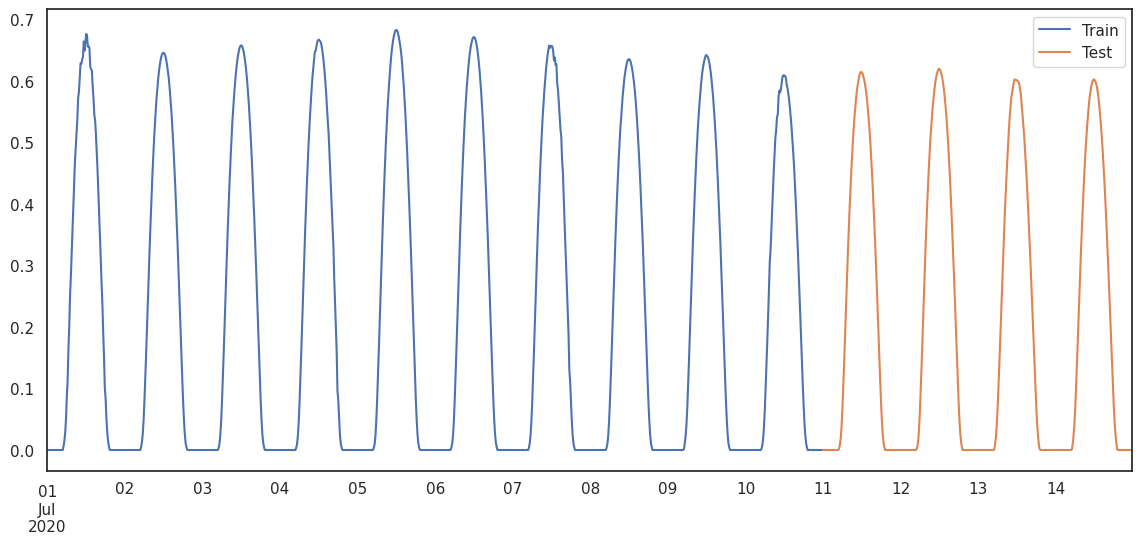

In [21]:
# Plot AC power training and testing date splits
_ = pd.DataFrame(y_train) \
    .rename(columns={'actual power': 'Train'}) \
    .join(pd.DataFrame(y_test).rename(columns={'actual power': 'Test'}), how='outer') \
    .plot(figsize=(14,6))

In [22]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Compute the accuracy errors : MAE, RMSE, R2 score.
def get_prediction_errors(y_true, y_pred):
    R2_score = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"R2 score: {R2_score}")
    print(f"MAE: {mae}")
    print(f"RMSE: {rmse}")
    return [R2_score, mae, rmse]

In [23]:
def plot_predictions(test, predicted):
    plt.figure(figsize=(14,6))
    plt.plot(test, label='Actual AC power', linewidth=3)
    plt.plot(predicted, label='Predicted AC power', linewidth=3)
    plt.xlabel('Time')
    plt.ylabel('AC Power Generated')
    plt.legend()
    plt.show()

In [24]:
def plot_forecast_day(test, predicted, forecast_pred, title = None):
    date_range = pd.date_range(start="2020-07-15 23:45:00", periods=len(forecast_pred), freq='15min')
    future_days = pd.DataFrame({'Date': date_range, 'Forecast': forecast_pred})
    future_days.index = future_days["Date"]
    plt.figure(figsize=(14,6))
    plt.plot(test, label='Actual AC power', linewidth=3)
    plt.plot(predicted, label='Predicted AC power', linewidth=3)
    plt.plot(future_days["Forecast"], label='Forecasted AC power', linewidth=3)
    plt.xlabel('Time')
    plt.ylabel('AC Power Generated')
    plt.legend()
    if title:
        plt.title(title)
    plt.show()

## Building ML Models

### 1- XGBoost :

In [25]:
import xgboost as xgb

xgboost = xgb.XGBRegressor(n_estimators=200,
                           learning_rate=0.01,
                           max_depth=5,
                           min_child_weight=10,
                           base_score=0.5
                          )
xgboost.fit(x_train, y_train, eval_set=[(x_train, y_train), (x_test, y_test)], verbose=0)

,objective,'reg:squarederror'
,base_score,0.5
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


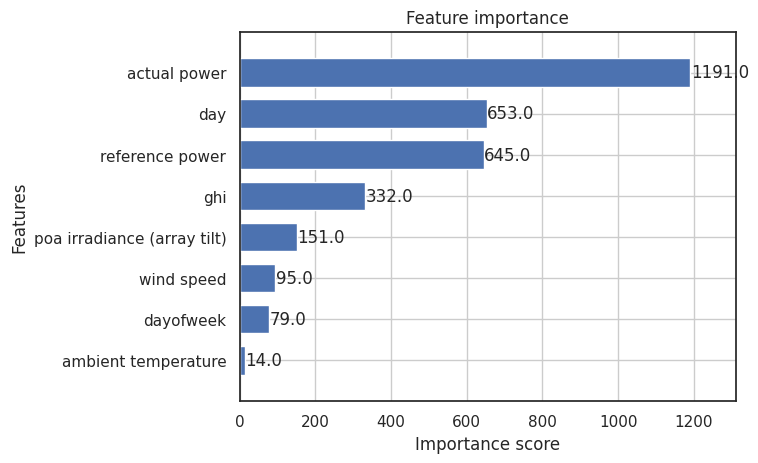

In [26]:
_ = xgb.plot_importance(xgboost, height=0.7)

In [27]:
predicted = xgboost.predict(x_test)
results = pd.concat([y_test, pd.Series(predicted, index=y_test.index)], axis=1)
results.index = data_all.index[-4*day:]
results.columns = ["Actual", "Predicted"]

In [28]:
xgb_errors = get_prediction_errors(results["Actual"], results["Predicted"])

R2 score: 0.9535036842181162
MAE: 0.046052984024679104
RMSE: 0.05164487740526043


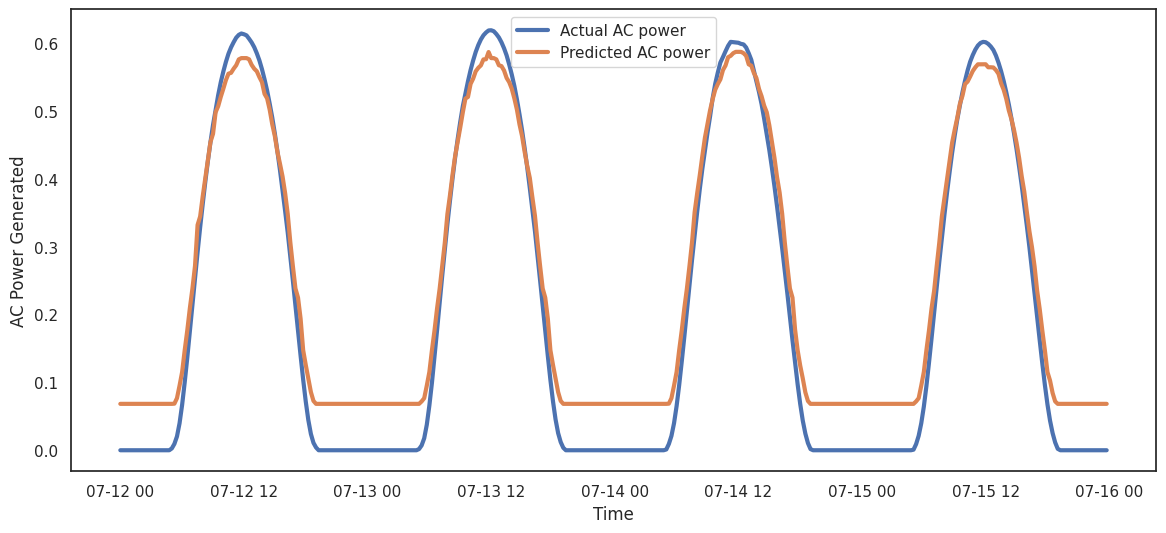

In [29]:
plot_predictions(results["Actual"], results["Predicted"])

### Forecast Next Future Day

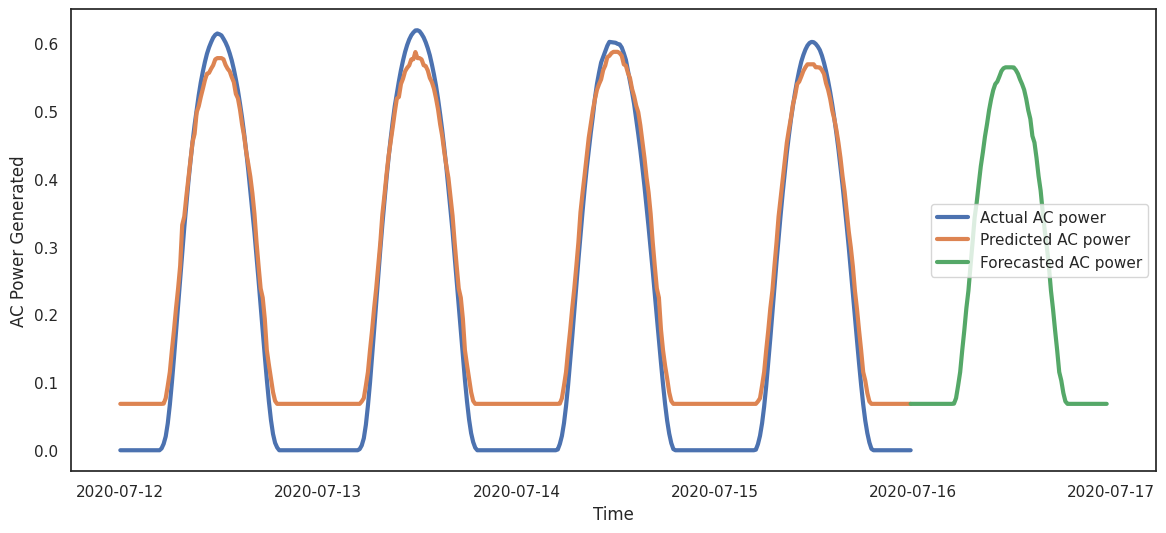

In [30]:
last_day = data_all["2020-07-15 00:00:00":]
last_day_pred = xgboost.predict(last_day)
plot_forecast_day(results["Actual"], results["Predicted"], last_day_pred)

In [31]:
results["Actual"]

2020-07-12 00:00:00    0.0
2020-07-12 00:15:00    0.0
2020-07-12 00:30:00    0.0
2020-07-12 00:45:00    0.0
2020-07-12 01:00:00    0.0
                      ... 
2020-07-15 22:45:00    0.0
2020-07-15 23:00:00    0.0
2020-07-15 23:15:00    0.0
2020-07-15 23:30:00    0.0
2020-07-15 23:45:00    0.0
Name: Actual, Length: 384, dtype: float64

In [32]:
last_day = data_all["2020-07-15 00:00:00":]
last_day_pred = xgboost.predict(last_day)


In [33]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, max_depth=7)
rf.fit(x_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


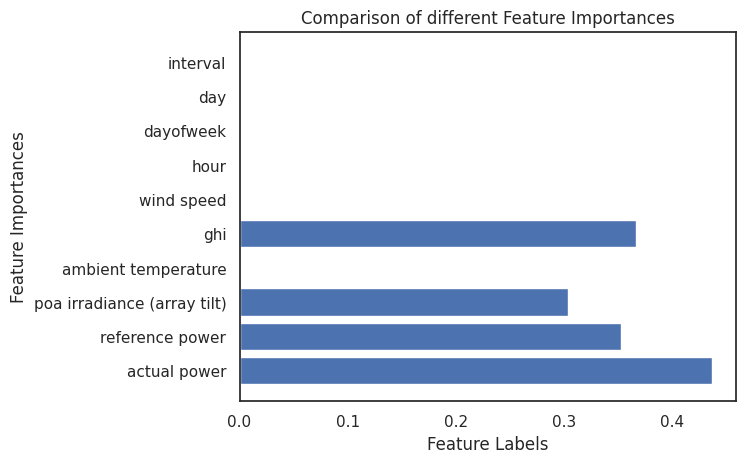

In [34]:
feature_importance = rf.feature_importances_

# Normalizing the individual importances
feature_importance_normalized = np.std([tree.feature_importances_ for tree in
                                        rf.estimators_],
                                        axis=0)

plt.barh(x_train.columns, feature_importance_normalized)
plt.xlabel('Feature Labels')
plt.ylabel('Feature Importances')
plt.title('Comparison of different Feature Importances')
plt.show()

In [35]:
results["Predicted"] = rf.predict(x_test)
rf_errors = get_prediction_errors(results["Actual"], results["Predicted"])

R2 score: 0.9985368123449343
MAE: 0.005206989671444743
RMSE: 0.009161529701634476


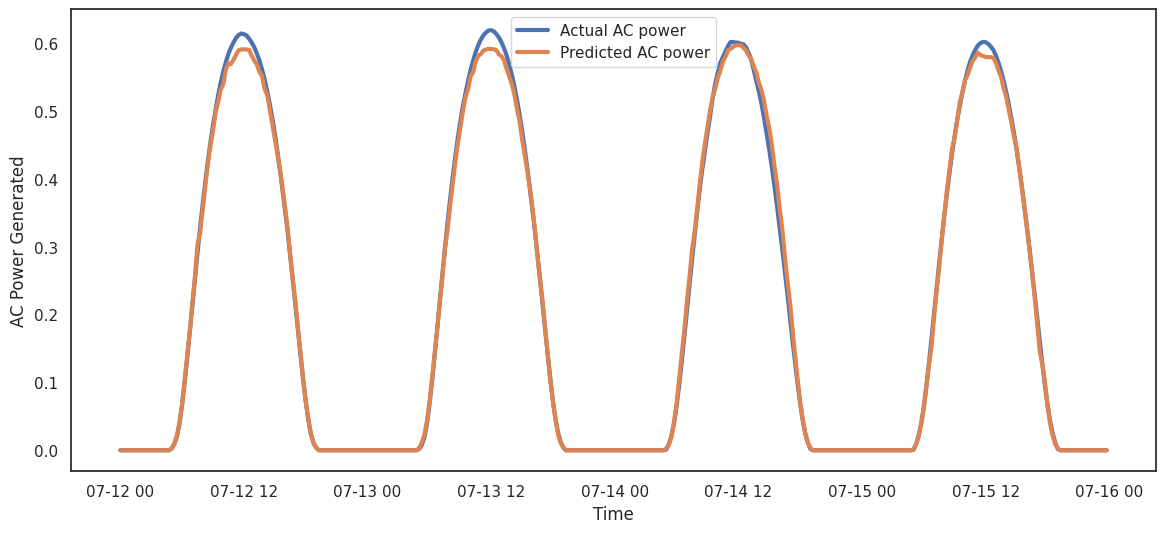

In [36]:
plot_predictions(results["Actual"], results["Predicted"])

### Forecast Next Future Day

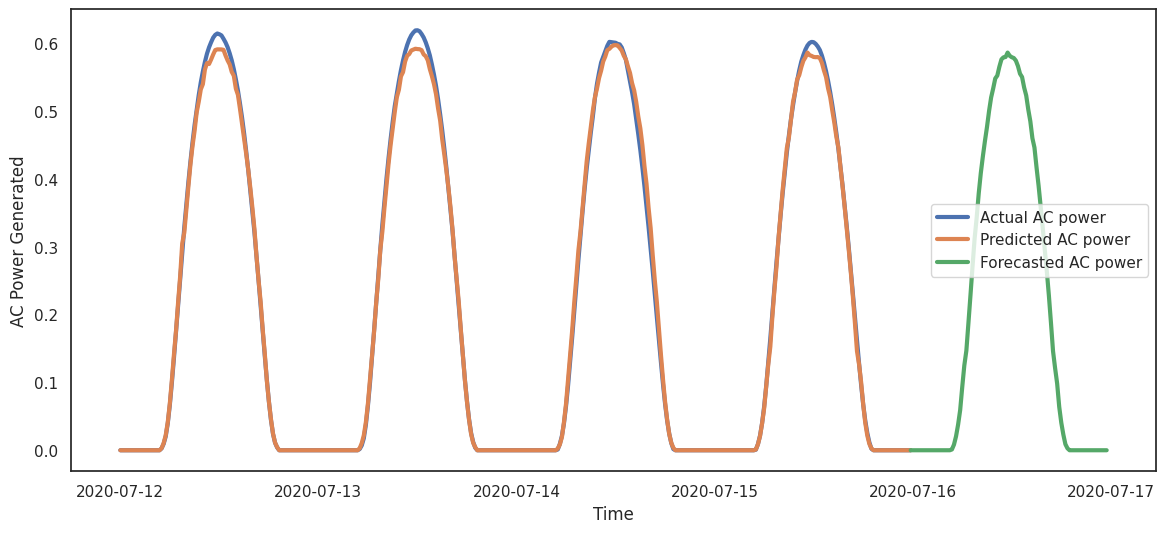

In [37]:
last_day_pred = rf.predict(last_day)
plot_forecast_day(results["Actual"], results["Predicted"], last_day_pred)

## LSTM Model

### 1- Data scaling

In [38]:
from sklearn.preprocessing import MinMaxScaler

def scale_data(data):
    features = data_all.iloc[:, 1:]
    target = data_all.iloc[:, 0]
    x_scaler = MinMaxScaler()
    X = pd.DataFrame(x_scaler.fit_transform(features))

    y_scaler = MinMaxScaler()
    Y = pd.DataFrame(y_scaler.fit_transform(target.values.reshape(-1, 1)))

    scaled_data = pd.concat([Y, X], axis=1)
    scaled_data.columns = data.columns

    return scaled_data, y_scaler

In [39]:
scaled_data, y_scaler = scale_data(data_all)

### 2- Construct Window Data

In [40]:
from sklearn.model_selection import TimeSeriesSplit

def create_lstm_data(data, past_days, future_days):
    """
    Create fixed-shape LSTM windows using deterministic sliding windows.
    - X arrays shape: (n_windows, train_size, n_features)
    - y arrays shape: (n_windows, test_size)
    """
    test_size = future_days * day
    train_size = past_days * day
    n = len(data)

    if n < train_size + test_size:
        raise ValueError("Not enough samples for requested past_days/future_days")

    # number of non-overlapping windows available
    max_windows = (n - train_size) // test_size
    if max_windows <= 0:
        raise ValueError("Not enough windows available given test_size/train_size")

    n_splits = min(30, max_windows)

    # ensure at least one training window; reserve last `future_days` windows for test
    cutoff = max(1, n_splits - future_days)

    X_train, y_train = [], []
    X_test, y_test = [], []

    for k in range(n_splits):
        train_end = train_size + k * test_size - 1
        train_start = train_end - train_size + 1
        test_start = train_end + 1
        test_end = test_start + test_size - 1

        if test_end >= n:
            break

        Xw = data.iloc[train_start: train_end + 1].values  # shape: train_size x n_features
        yw = data['actual power'].iloc[test_start: test_end + 1].values  # length: test_size

        if k < cutoff:
            X_train.append(Xw)
            y_train.append(yw)
        else:
            X_test.append(Xw)
            y_test.append(yw)

    if len(X_train) == 0:
        raise ValueError("No training windows created. Reduce future_days or provide more data.")

    return np.array(X_train), np.array(y_train), np.array(X_test), np.array(y_test)

In [41]:
X_train, Y_train, X_test, Y_test = create_lstm_data(scaled_data, 3, 1)

### 3- Build & train LSTM

In [42]:
import tensorflow as tf
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

lstm_model = Sequential()
lstm_model.add(LSTM(256, return_sequences=True, kernel_initializer=tf.initializers.zeros() , input_shape=X_train.shape[1:]))
lstm_model.add(Dropout(0.3))
lstm_model.add(LSTM(256, kernel_initializer=tf.initializers.zeros()))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(day))
lstm_model.summary()

2025-11-09 15:22:50.243791: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-09 15:22:50.474737: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-09 15:23:03.850424: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-09 15:23:13.300834: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 288, 256)       │       273,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 288, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 96)             │        24,672 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 823,392 (3.14 MB)

 Trainable params: 823,392 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=20,
                                                    mode='min',
                                                    restore_best_weights=True)

lstm_model.compile(optimizer="adam", loss="MSE")
lstm_model.fit(X_train, Y_train, validation_data=(X_test, Y_test), epochs=200, callbacks=[early_stopping], verbose=0)

<Axes: >

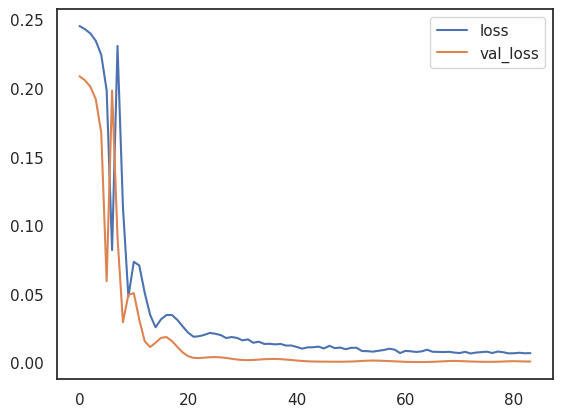

In [44]:
history = pd.DataFrame(lstm_model.history.history)
history.plot()

In [45]:
# construct 3 days window data to predict the AC power of last 3 days
input_test_day_1 = np.array(scaled_data.iloc[-6*day:-3*day, :])
input_test_day_2 = np.array(scaled_data.iloc[-5*day:-2*day, :])
input_test_day_3 = np.array(scaled_data.iloc[-3*day:, :])
input_test_days = np.array([input_test_day_1, input_test_day_2, input_test_day_3])

In [46]:

# Predict with LSTM
lstm_predictions = lstm_model.predict(input_test_days)

# Select last 3 days of actual data
y_test = data_all.iloc[-3*day:, 0]

# Inverse transform predictions
y_pred = y_scaler.inverse_transform(lstm_predictions.reshape(-1, 1)).flatten()

# # Remove NaNs from both arrays
# mask = ~np.isnan(y_test) & ~np.isnan(y_pred)
# y_test_clean = y_test[mask]
# y_pred_clean = y_pred[mask]

# Compute errors safely
lstm_errors = get_prediction_errors(y_test, y_pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step
R2 score: 0.9973382194452721
MAE: 0.010075102269599512
RMSE: 0.012315876513414885


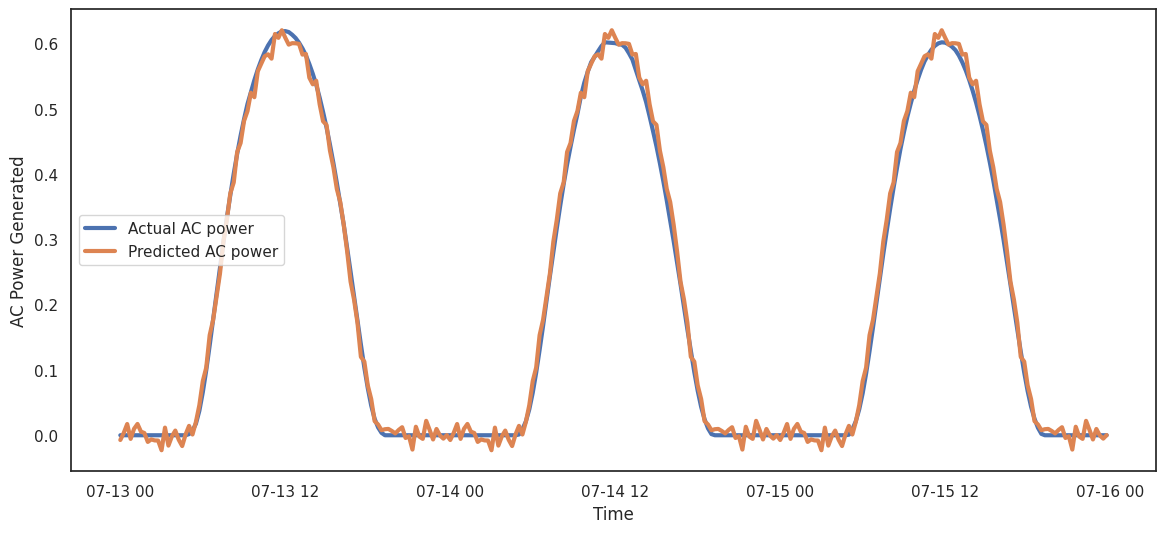

In [47]:
results = pd.concat([y_test, pd.Series(y_pred, index=y_test.index)], axis=1)
results.index = data_all.index[-3*day:]
results.columns = ["Actual", "Predicted"]
plot_predictions(results["Actual"], results["Predicted"])

### Forecast Next Future Day

In [48]:
last_day = np.array(scaled_data)[-3*day:, :]
last_day_arr = np.array([last_day])
future_day_pred = lstm_model.predict(last_day_arr)
future_pred = y_scaler.inverse_transform(future_day_pred.reshape(day, 1)).reshape(-1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step


In [49]:
stats = pd.DataFrame([xgb_errors, rf_errors, lstm_errors],
                     columns=["R2 score", "MAE", "RMSE"],
                     index=["XGBoost", "RandomForest", "LSTM"]
                     )

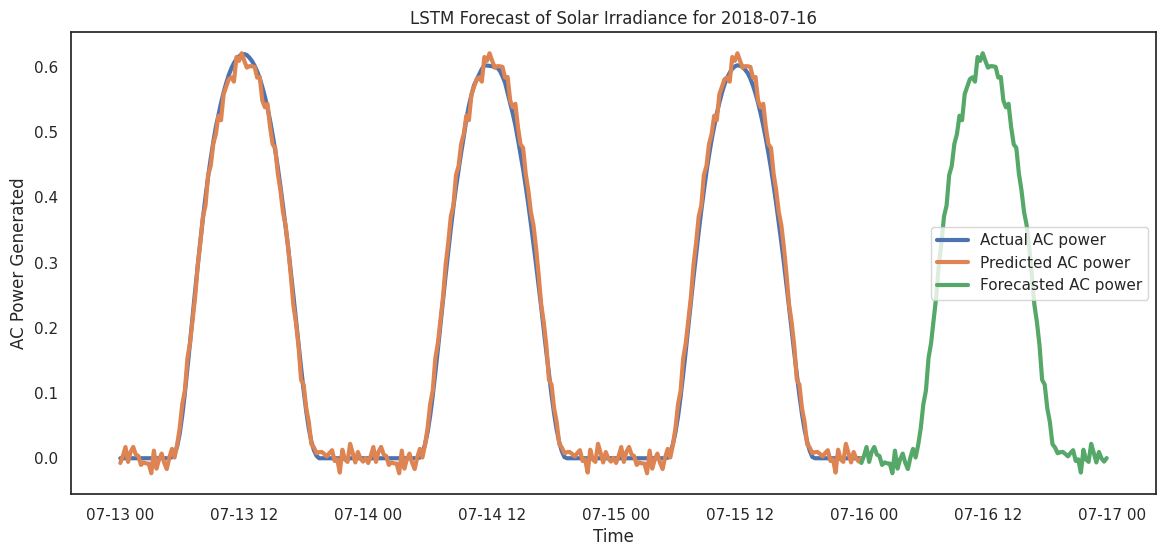

final results:


,R2 score,MAE,RMSE
XGBoost,0.953504,0.046053,0.051645
RandomForest,0.998537,0.005207,0.009162
LSTM,0.997338,0.010075,0.012316


In [50]:
plot_forecast_day(results["Actual"], results["Predicted"], future_pred, title="LSTM Forecast of Solar Irradiance for 2018-07-16")
print('final results:')
stats.head()